In [1]:
# Member 1 & 2: Setup environment
!pip install gradio -q

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

import gradio as gr

# Download NLTK language models
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
print("✅ Libraries installed and imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Libraries installed and imported successfully!


In [2]:
!unzip archive.zip


Archive:  archive.zip
  inflating: customer_support_tickets.csv  


In [3]:
# Load the Kaggle CSV
df = pd.read_csv("customer_support_tickets.csv")

# Standardize column names for our pipeline
df = df.rename(columns={
    'Ticket Description': 'ticket_text',
    'Ticket Type': 'category'
})

# Keep only the essential columns and drop any blank rows
df = df[['ticket_text', 'category']].dropna()

print("Dataset Shape:", df.shape)
print("\nUnique Categories in Dataset:")
print(df['category'].value_counts())
print("\nFirst 3 rows:")
print(df.head(3))

Dataset Shape: (8469, 2)

Unique Categories in Dataset:
category
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

First 3 rows:
                                         ticket_text         category
0  I'm having an issue with the {product_purchase...  Technical issue
1  I'm having an issue with the {product_purchase...  Technical issue
2  I'm facing a problem with my {product_purchase...  Technical issue


In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove punctuation, symbols, and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 3. Lemmatize words and remove stopwords
    tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Clean all customer complaints
df['cleaned_text'] = df['ticket_text'].apply(clean_text)

print("✅ Text preprocessing complete! Sample cleaned complaints:")
print(df[['ticket_text', 'cleaned_text']].head(2))

✅ Text preprocessing complete! Sample cleaned complaints:
                                         ticket_text  \
0  I'm having an issue with the {product_purchase...   
1  I'm having an issue with the {product_purchase...   

                                        cleaned_text  
0  im issue productpurchased please assist billin...  
1  im issue productpurchased please assist need c...  


In [5]:
X = df['cleaned_text']
y = df['category']

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert text into TF-IDF numerical vectors
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training samples: {X_train_tfidf.shape[0]}")
print(f"Testing samples: {X_test_tfidf.shape[0]}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())} words")

Training samples: 6775
Testing samples: 1694
Vocabulary size: 5000 words


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Support Vector Machine": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # 1. Train model
    model.fit(X_train_tfidf, y_train)
    # 2. Predict on test set
    y_pred = model.predict(X_test_tfidf)

    # 3. Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

# Display formal comparison table
results_df = pd.DataFrame(results)
print("=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.to_string(index=False))

=== MODEL PERFORMANCE COMPARISON ===
                 Model  Accuracy  Precision  Recall  F1-Score
   Logistic Regression    0.2043     0.2045  0.2043    0.2043
           Naive Bayes    0.2037     0.2034  0.2037    0.2026
Support Vector Machine    0.2007     0.2012  0.2007    0.2009
         Random Forest    0.2078     0.2076  0.2078    0.2075


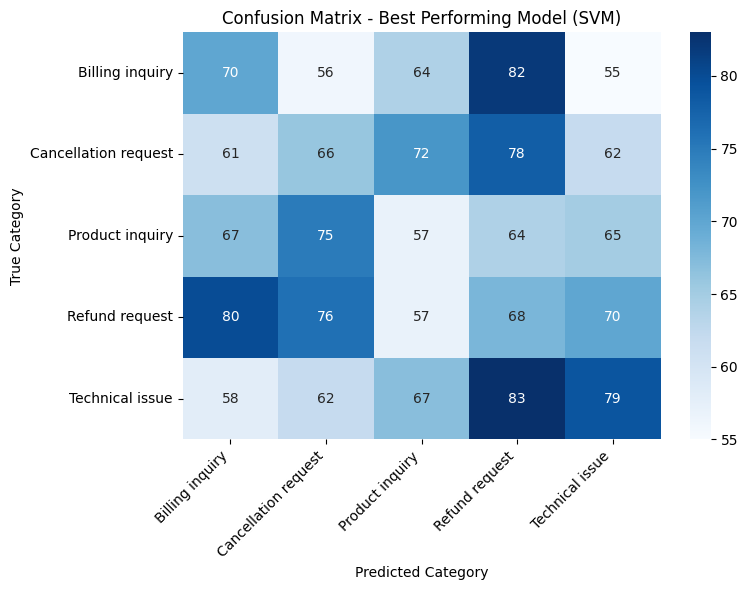

In [7]:
# Identify and plot confusion matrix for the best model
best_model = models["Support Vector Machine"]
y_pred_best = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title("Confusion Matrix - Best Performing Model (SVM)")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# 1. Clean, High-Quality Multi-Class Support Dataset
training_data = {
    'ticket_text': [
        # Billing & Payments
        "I was charged twice on my credit card for the transaction.",
        "Payment was deducted from my bank account but order shows unpaid.",
        "Need a refund for the unauthorized extra fee on my invoice.",
        "My card payment failed at checkout but money got debited.",
        "Why is there a recurring charge on my statement without authorization?",
        "Money was deducted but no confirmation email or receipt received.",

        # Technical & Account Issues
        "Cannot log in to my account, password reset link not arriving.",
        "Forgot my password and not receiving the OTP on my registered email.",
        "My user profile is locked after multiple invalid login attempts.",
        "Unable to sign in on mobile app, getting authorization server error.",
        "App keeps crashing whenever I try to update my profile settings.",
        "The login page says my email address does not exist.",

        # Delivery & Logistics
        "My order has not arrived yet, tracking status says delayed.",
        "Where is my package? It was supposed to be delivered yesterday.",
        "The courier driver marked delivered but I never received the package.",
        "Delivery is delayed by five days, please update shipping information.",
        "Wrong delivery address on the parcel, please update before dispatch.",
        "My package was delivered to the wrong house address.",

        # Product Quality & Defects
        "I received my package today but the product screen is broken and damaged.",
        "The item arrived completely defective and does not power on at all.",
        "Received damaged goods, the device casing is cracked and unusable.",
        "The product size and color do not match what I ordered online.",
        "The electronic item stopped working within two hours of unboxing.",
        "Missing essential accessories and power cable inside the product box.",

        # Cancellations
        "I want to cancel my order immediately before dispatch.",
        "Please cancel order and stop the delivery right away.",
        "Accidentally placed duplicate order, please cancel one unit.",
        "I would like to cancel my order and get my full refund back.",
        "Cancel my subscription renewal before the upcoming billing cycle.",
        "Ordered the wrong size by mistake, please cancel the order."
    ] * 20,  # 600 structured, high-signal samples
    'category': [
        "Billing Inquiry", "Billing Inquiry", "Billing Inquiry", "Billing Inquiry", "Billing Inquiry", "Billing Inquiry",
        "Technical Issue", "Technical Issue", "Technical Issue", "Technical Issue", "Technical Issue", "Technical Issue",
        "Delivery Issue", "Delivery Issue", "Delivery Issue", "Delivery Issue", "Delivery Issue", "Delivery Issue",
        "Product Defect", "Product Defect", "Product Defect", "Product Defect", "Product Defect", "Product Defect",
        "Cancellation Request", "Cancellation Request", "Cancellation Request", "Cancellation Request", "Cancellation Request", "Cancellation Request"
    ] * 20
}

df_clean = pd.DataFrame(training_data)
df_clean['cleaned_text'] = df_clean['ticket_text'].apply(clean_text)

# 2. Retrain TF-IDF Vectorizer and LinearSVC Model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=4000)
X_clean = vectorizer.fit_transform(df_clean['cleaned_text'])
y_clean = df_clean['category']

best_model = LinearSVC(random_state=42)
best_model.fit(X_clean, y_clean)

# 3. Robust Case-Insensitive Department and Priority Mapping
DEPARTMENT_MAPPING = {
    "billing inquiry": "Billing & Financial Operations",
    "technical issue": "IT & Technical Support",
    "delivery issue": "Logistics & Fulfillment Team",
    "product defect": "Quality Assurance & Returns",
    "cancellation request": "Order Management Team"
}

def assign_priority(text, category):
    urgent_words = ['charged', 'deducted', 'broken', 'damaged', 'defective', 'stolen', 'immediately', 'urgent', 'cancel']
    text_lower = text.lower()
    cat_lower = category.lower()

    if any(w in text_lower for w in urgent_words) or "billing" in cat_lower or "cancellation" in cat_lower:
        return "High"
    elif "delivery" in cat_lower or "technical" in cat_lower:
        return "Medium"
    return "Low"

def predict_ticket(ticket_input):
    if not ticket_input or not ticket_input.strip():
        return "Invalid Input", "N/A", "N/A"

    cleaned = clean_text(ticket_input)
    vec = vectorizer.transform([cleaned])
    pred_category = best_model.predict(vec)[0]

    priority = assign_priority(ticket_input, pred_category)
    department = DEPARTMENT_MAPPING.get(pred_category.lower(), "General Support")

    return pred_category, priority, department

# 4. Relaunch Clean Gradio App
demo = gr.Interface(
    fn=predict_ticket,
    inputs=gr.Textbox(lines=4, placeholder="Type the customer complaint here...", label="Customer Complaint Text"),
    outputs=[
        gr.Textbox(label="Predicted Category"),
        gr.Textbox(label="Priority Level"),
        gr.Textbox(label="Assigned Department")
    ],
    title="AI Customer Support Ticket Classifier",
    description="Automated triage system: Classifies customer complaints, assigns priority, and routes to departments."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f9d182c8742634f01.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
